In [46]:
import quantumsim_performante.quantumutil as QuantumUtil
from maxcut import show_graph, show_graph_partition, qaoa_circuit_noisy, qaoa_circuit, maxcut_bruteforce, cut_size, compute_partition, compute_average_cut_size
import networkx as nx
import numpy as np

# Creating graph

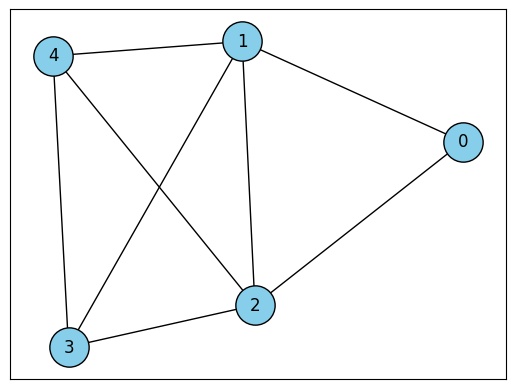

In [3]:
# Define nodes and edges
nodes = [0, 1, 2, 3, 4]
edges = [(0,1), (0,2), (1,2), (1,3), (2,3), (1,4), (2,4), (3,4)]

# Construct the graph
G = nx.Graph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)

show_graph(G.nodes, G.edges)

# Bruteforce

Partition #0: {0: 0, 1: 0, 2: 0, 3: 0, 4: 0} has cut size 0
Partition #1: {0: 0, 1: 0, 2: 0, 3: 0, 4: 1} has cut size 3
Partition #2: {0: 0, 1: 0, 2: 0, 3: 1, 4: 0} has cut size 3
Partition #3: {0: 0, 1: 0, 2: 0, 3: 1, 4: 1} has cut size 4
Partition #4: {0: 0, 1: 0, 2: 1, 3: 0, 4: 0} has cut size 4
Partition #5: {0: 0, 1: 0, 2: 1, 3: 0, 4: 1} has cut size 5
Partition #6: {0: 0, 1: 0, 2: 1, 3: 1, 4: 0} has cut size 5
Partition #7: {0: 0, 1: 0, 2: 1, 3: 1, 4: 1} has cut size 4
Partition #8: {0: 0, 1: 1, 2: 0, 3: 0, 4: 0} has cut size 4
Partition #9: {0: 0, 1: 1, 2: 0, 3: 0, 4: 1} has cut size 5
Partition #10: {0: 0, 1: 1, 2: 0, 3: 1, 4: 0} has cut size 5
Partition #11: {0: 0, 1: 1, 2: 0, 3: 1, 4: 1} has cut size 4
Partition #12: {0: 0, 1: 1, 2: 1, 3: 0, 4: 0} has cut size 6
Partition #13: {0: 0, 1: 1, 2: 1, 3: 0, 4: 1} has cut size 5
Partition #14: {0: 0, 1: 1, 2: 1, 3: 1, 4: 0} has cut size 5
Partition #15: {0: 0, 1: 1, 2: 1, 3: 1, 4: 1} has cut size 2
Partition #16: {0: 1, 1: 0, 2: 0, 

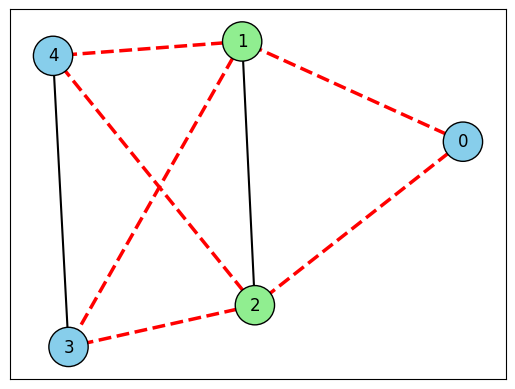

In [15]:
partitions, max_cut_index = maxcut_bruteforce(G.nodes, G.edges)
for (i, partition) in enumerate(partitions):
    print(f"Partition #{i}: {partition[0]} has cut size {partition[1]}")
print(f"Maxcut is {partitions[max_cut_index][0]}, cut-size is {partitions[max_cut_index][1]}")

partition = partitions[max_cut_index][0]
show_graph_partition(G.nodes, G.edges, partition)

In [27]:
sum = 0
for partition in partitions:
    sum += partition[1]
avg = sum/len(partitions)

print(f"Average cut-size of bruteforce: {avg}")

Average cut-size of bruteforce: 4.0


# QAOA

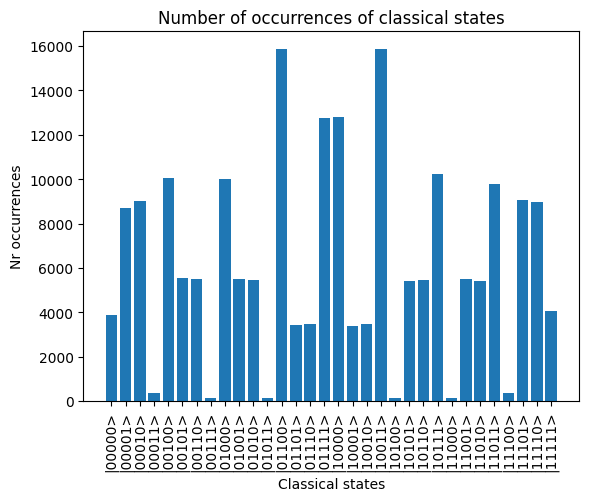

In [34]:
gamma = [np.pi/8]
beta = [np.pi/3]
nr_measurements = 200000
circuit = qaoa_circuit(gamma, beta, G.nodes, G.edges, 1)
result = QuantumUtil.measure_circuit(circuit, nr_measurements=nr_measurements)
QuantumUtil.histogram_of_classical_states(result)

Average cut size is 4.442095
Partition {0: 0, 1: 0, 2: 1, 3: 0, 4: 1} has cut size 5


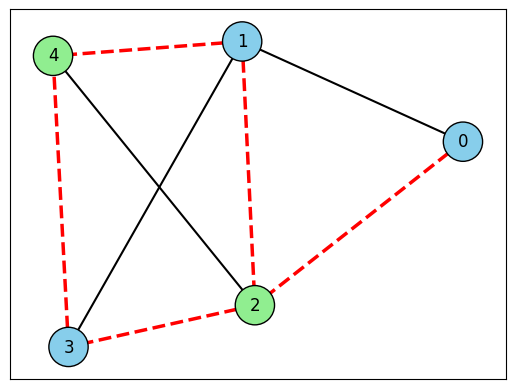

In [30]:
average_cut_size = compute_average_cut_size(nodes, edges, result)
partition = compute_partition(G.nodes, G.edges, result)
partition_cut_size = cut_size(G.edges, partition)

print(f"Average cut size is {average_cut_size}")
print(f"Partition {partition} has cut size {partition_cut_size}")
show_graph_partition(G.nodes, G.edges, partition)

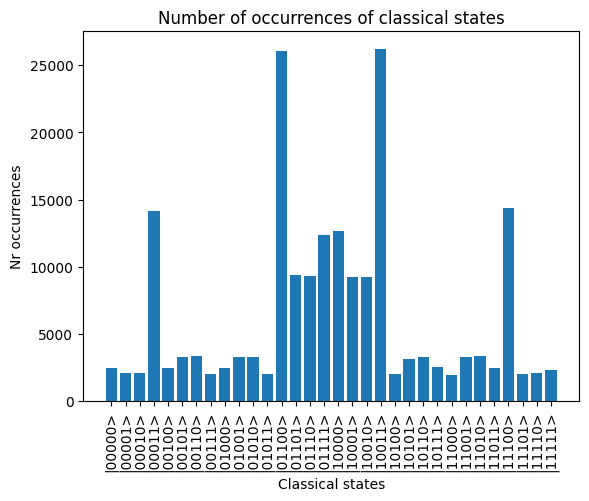

In [32]:
p = 2
gamma = [np.pi/8] * p
beta = [np.pi/3] * p
nr_measurements = 200000
circuit = qaoa_circuit(gamma, beta, nodes, edges, p)
result = QuantumUtil.measure_circuit(circuit, nr_measurements=nr_measurements)

QuantumUtil.histogram_of_classical_states(result)

Average cut size is 4.45169
Partition {0: 1, 1: 0, 2: 0, 3: 1, 4: 1} has cut size 6


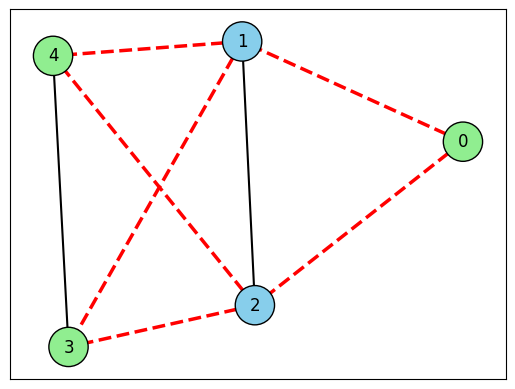

In [33]:
average_cut_size = compute_average_cut_size(nodes, edges, result)
partition = compute_partition(nodes, edges, result)
partition_cut_size = cut_size(edges, partition)

print(f"Average cut size is {average_cut_size}")
print(f"Partition {partition} has cut size {partition_cut_size}")
show_graph_partition(nodes, edges, partition)

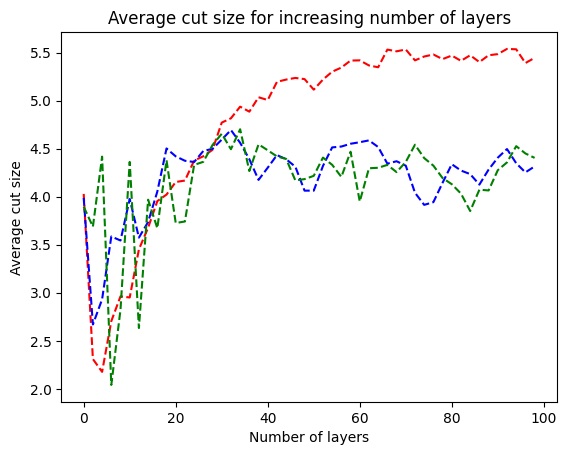

In [26]:
import matplotlib.pyplot as plt

nr_measurements = 1000
p_max = 100
p_step = 2

average_cut_size1 = []
gemma_base = 1.0
beta_base = 1.0
for p in range(0, p_max, p_step):
    gamma = []
    beta = []
    for i in range(p):
        gamma.append((gemma_base) * (i/p))
        beta.append((beta_base) * ((p - i)/p))
    circuit = qaoa_circuit(gamma, beta, nodes, edges, p)
    result = QuantumUtil.measure_circuit(circuit, nr_measurements=nr_measurements)
    average_cut_size1.append(compute_average_cut_size(nodes, edges, result))

average_cut_size2 = []
gemma_base = 1.1
beta_base = 1.1
for p in range(0, p_max, p_step):
    gamma = []
    beta = []
    for i in range(p):
        gamma.append((gemma_base) * (i/p))
        beta.append((beta_base) * ((p - i)/p))
    circuit = qaoa_circuit(gamma, beta, nodes, edges, p)
    result = QuantumUtil.measure_circuit(circuit, nr_measurements=nr_measurements)
    average_cut_size2.append(compute_average_cut_size(nodes, edges, result))

average_cut_size3 = []
gemma_base = 2.0
beta_base = 2.0
for p in range(0, p_max, p_step):
    gamma = []
    beta = []
    for i in range(p):
        gamma.append((gemma_base) * (i/p))
        beta.append((beta_base) * ((p - i)/p))
    circuit = qaoa_circuit(gamma, beta, nodes, edges, p)
    result = QuantumUtil.measure_circuit(circuit, nr_measurements=nr_measurements)
    average_cut_size3.append(compute_average_cut_size(nodes, edges, result))

plt.plot(list(range(0, p_max, p_step)), average_cut_size1, "r--")
plt.plot(list(range(0, p_max, p_step)), average_cut_size2, "b--")
plt.plot(list(range(0, p_max, p_step)), average_cut_size3, "g--")
plt.title('Average cut size for increasing number of layers')
plt.xlabel('Number of layers')
plt.ylabel('Average cut size')
plt.show()

In [ ]:
p = 50
nr_steps = 32
nr_measurements = 1000
landscape = np.zeros((nr_steps, nr_steps), dtype=float)
for i in range(nr_steps):
    gamma_max = i*(np.pi/nr_steps)
    for j in range(nr_steps):
        beta_max = j*(np.pi/nr_steps)
        gamma = []
        beta = []
        for layer in range(p):
            gamma.append(gamma_max * (layer/p))
            beta.append(beta_max * ((p - layer)/p))
        circuit = qaoa_circuit(gamma, beta, nodes, edges, p)
        result = QuantumUtil.measure_circuit(circuit, nr_measurements=nr_measurements)
        average_cut_size = compute_average_cut_size(nodes, edges, result)
        landscape[i,j] = average_cut_size

i: 0 - j : 0
i: 0 - j : 1
i: 0 - j : 2
i: 0 - j : 3
i: 0 - j : 4
i: 0 - j : 5
i: 0 - j : 6
i: 0 - j : 7
i: 0 - j : 8
i: 0 - j : 9
i: 0 - j : 10
i: 0 - j : 11
i: 0 - j : 12
i: 0 - j : 13
i: 0 - j : 14
i: 0 - j : 15
i: 0 - j : 16
i: 0 - j : 17
i: 0 - j : 18
i: 0 - j : 19
i: 0 - j : 20
i: 0 - j : 21
i: 0 - j : 22
i: 0 - j : 23
i: 0 - j : 24
i: 0 - j : 25
i: 0 - j : 26
i: 0 - j : 27
i: 0 - j : 28
i: 0 - j : 29
i: 0 - j : 30
i: 0 - j : 31
i: 1 - j : 0
i: 1 - j : 1
i: 1 - j : 2
i: 1 - j : 3
i: 1 - j : 4
i: 1 - j : 5
i: 1 - j : 6
i: 1 - j : 7
i: 1 - j : 8
i: 1 - j : 9
i: 1 - j : 10
i: 1 - j : 11
i: 1 - j : 12
i: 1 - j : 13
i: 1 - j : 14
i: 1 - j : 15
i: 1 - j : 16
i: 1 - j : 17
i: 1 - j : 18
i: 1 - j : 19
i: 1 - j : 20
i: 1 - j : 21
i: 1 - j : 22
i: 1 - j : 23
i: 1 - j : 24
i: 1 - j : 25
i: 1 - j : 26
i: 1 - j : 27
i: 1 - j : 28
i: 1 - j : 29
i: 1 - j : 30
i: 1 - j : 31
i: 2 - j : 0
i: 2 - j : 1
i: 2 - j : 2
i: 2 - j : 3
i: 2 - j : 4
i: 2 - j : 5
i: 2 - j : 6
i: 2 - j : 7


KeyboardInterrupt: 

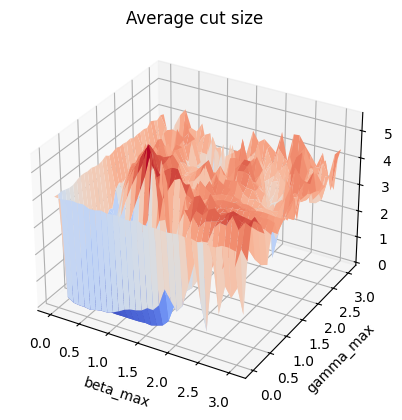

In [ ]:
from matplotlib import cm

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = np.arange(0, np.pi, np.pi/nr_steps)
y = np.arange(0, np.pi, np.pi/nr_steps)
X, Y = np.meshgrid(x, y)
Z = landscape

ax.plot_surface(X, Y, Z, cmap=cm.coolwarm)
plt.title('Average cut size')
plt.xlabel('beta_max')
plt.ylabel('gamma_max')
plt.show()

In [11]:
from scipy.optimize import minimize

def optimization(parameters):
    gamma, beta = parameters
    circuit = qaoa_circuit([gamma], [beta], nodes, edges, p=1)
    result = QuantumUtil.measure_circuit(circuit, nr_measurements=nr_measurements)
    average_cut_size = compute_average_cut_size(nodes, edges, result)
    return -average_cut_size

res = minimize(optimization, [np.pi/2, np.pi/2], method='COBYLA')
print(res)

gamma = res.x[0]
beta = res.x[1]
print(f"gamma = {gamma}")
print(f"beta = {beta}")

 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -4.359
       x: [ 1.291e+00  2.003e+00]
    nfev: 33
   maxcv: 0.0
gamma = 1.2913793928465924
beta = 2.003325705103205


Average cut size is 4.327795
Partition {0: 1, 1: 0, 2: 0, 3: 1, 4: 1} has cut size 6


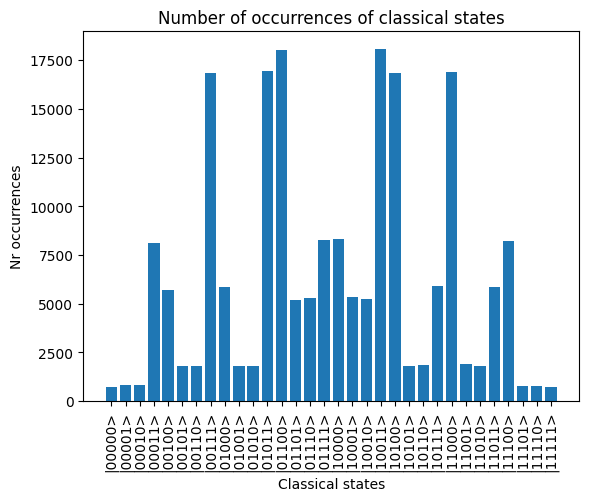

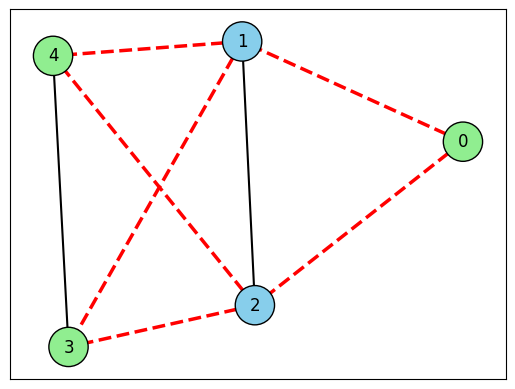

In [ ]:
nr_measurements = 200000
circuit = qaoa_circuit([gamma], [beta], nodes, edges, p=1)
result = QuantumUtil.measure_circuit(circuit, nr_measurements=nr_measurements)

average_cut_size = compute_average_cut_size(nodes, edges, result)
partition = compute_partition(nodes, edges, result)
partition_cut_size = cut_size(edges, partition)

print(f"Average cut size is {average_cut_size}")
print(f"Partition {partition} has cut size {partition_cut_size}")
QuantumUtil.histogram_of_classical_states(result)
show_graph_partition(nodes, edges, partition)

In [13]:
from scipy.optimize import minimize

def optimization(parameters):
    p = 50
    gamma_max, beta_max = parameters
    gamma = []
    beta = []
    for layer in range(p):
        gamma.append(gamma_max * (layer/p))
        beta.append(beta_max * ((p - layer)/p))
    circuit = qaoa_circuit(gamma, beta, nodes, edges, p=p)
    result = QuantumUtil.measure_circuit(circuit, nr_measurements=nr_measurements)
    average_cut_size = compute_average_cut_size(nodes, edges, result)
    return -average_cut_size

bounds = [(0, np.pi), (0, np.pi)]
res = minimize(optimization, [np.pi/2, np.pi/2], bounds=bounds, method='COBYLA')
print(res)

gamma_max = res.x[0]
beta_max = res.x[1]
print(f"gamma_max = {gamma_max}")
print(f"beta_max = {beta_max}")

 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -4.67284
       x: [ 2.564e+00  2.584e+00]
    nfev: 35
   maxcv: 0.0
gamma_max = 2.564383993829948
beta_max = 2.5839223662354627


Partition {0: 1, 1: 0, 2: 0, 3: 1, 4: 1} has cut size 6
Average cut size is 4.669745


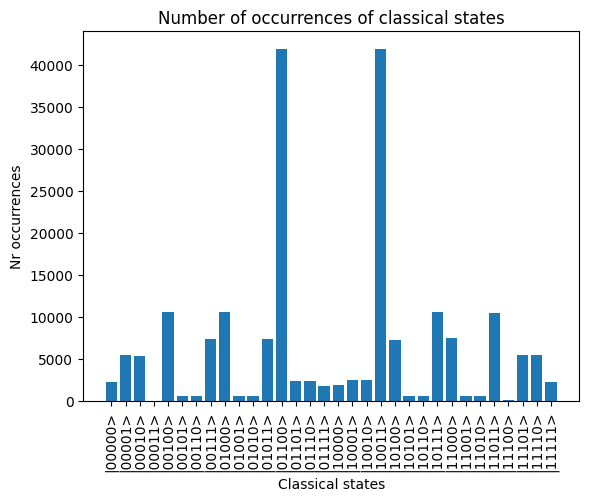

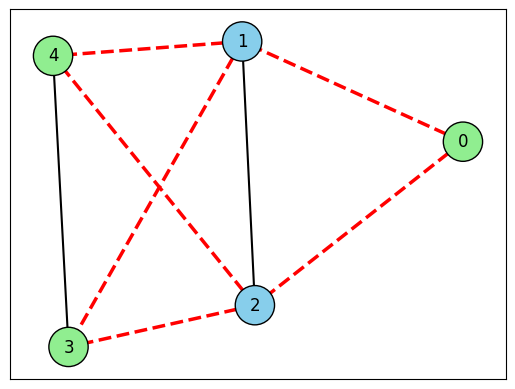

In [ ]:
nr_measurements = 200000
p = 50
gamma = []
beta = []
for layer in range(p):
    gamma.append(gamma_max * (layer/p))
    beta.append(beta_max * ((p - layer)/p))
circuit = qaoa_circuit(gamma, beta, nodes, edges, p=p)
result = QuantumUtil.measure_circuit(circuit, nr_measurements=nr_measurements)

average_cut_size = compute_average_cut_size(nodes, edges, result)
partition = compute_partition(nodes, edges, result)
partition_cut_size = cut_size(edges, partition)

print(f"Partition {partition} has cut size {partition_cut_size}")
print(f"Average cut size is {average_cut_size}")
QuantumUtil.histogram_of_classical_states(result)
show_graph_partition(nodes, edges, partition)

Partition {0: 0, 1: 1, 2: 1, 3: 0, 4: 0} has cut size 6
Average cut size is 5.19232


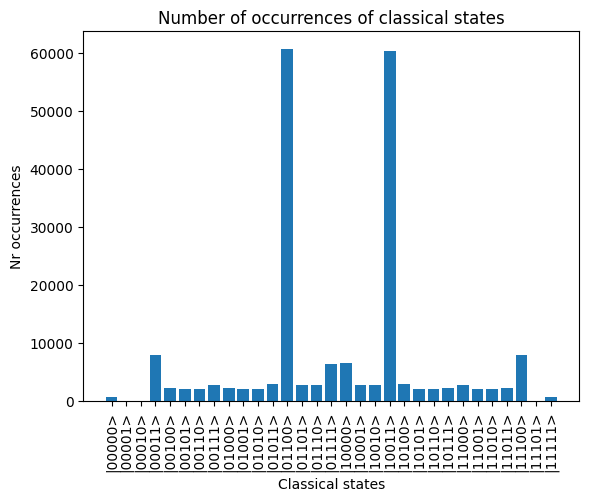

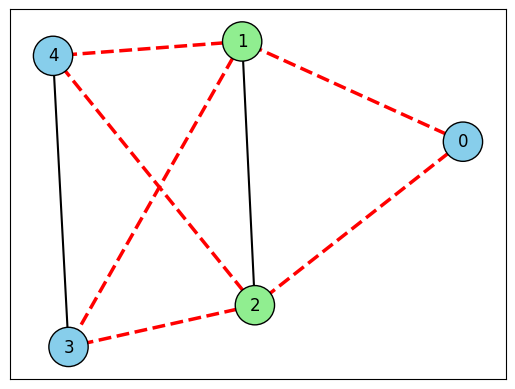

In [ ]:
nr_measurements = 200000
p = 50
gamma_max = 1.0
beta_max = 1.0
gamma = []
beta = []
for layer in range(p):
    gamma.append(gamma_max * (layer/p))
    beta.append(beta_max * ((p - layer)/p))
circuit = qaoa_circuit(gamma, beta, nodes, edges, p=p)
result = QuantumUtil.measure_circuit(circuit, nr_measurements=nr_measurements)

average_cut_size = compute_average_cut_size(nodes, edges, result)
partition = compute_partition(nodes, edges, result)
partition_cut_size = cut_size(edges, partition)

print(f"Partition {partition} has cut size {partition_cut_size}")
print(f"Average cut size is {average_cut_size}")
QuantumUtil.histogram_of_classical_states(result)
show_graph_partition(nodes, edges, partition)

# Noisy QAOA

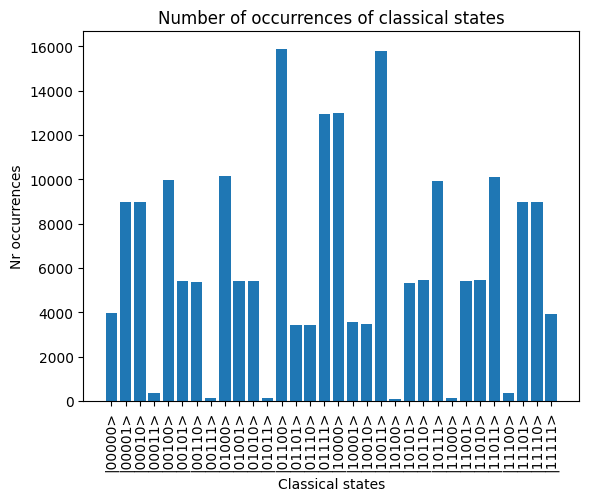

In [10]:
gamma = [np.pi/8]
beta = [np.pi/3]
nr_measurements = 200000
circuit = qaoa_circuit(gamma, beta, nodes, edges, 1)
result = QuantumUtil.measure_circuit(circuit, nr_measurements=nr_measurements)
QuantumUtil.histogram_of_classical_states(result)

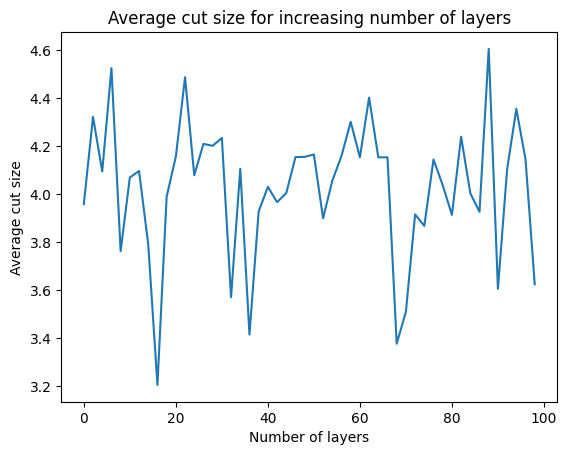

In [ ]:
import matplotlib.pyplot as plt

nr_measurements = 1000
average_cut_size = []
p_max = 100
p_step = 2

gemma_base = 1.0
beta_base = 1.0

for p in range(0, p_max, p_step):
    gamma = []
    beta = []
    for i in range(p):
        gamma.append((gemma_base) * (i/p))
        beta.append((beta_base) * ((p - i)/p))
    circuit = qaoa_circuit_noisy(gamma, beta, nodes, edges, p)
    result = QuantumUtil.measure_circuit(circuit, nr_measurements=nr_measurements)
    average_cut_size.append(compute_average_cut_size(nodes, edges, result))

plt.plot(list(range(0, p_max, p_step)), average_cut_size)
plt.title('Average cut size for increasing number of layers')
plt.xlabel('Number of layers')
plt.ylabel('Average cut size')
plt.show()

In [55]:
from scipy.optimize import minimize

def optimization(parameters):
    p = 50
    gamma_max, beta_max = parameters
    gamma = []
    beta = []
    for layer in range(p):
        gamma.append(gamma_max * (layer/p))
        beta.append(beta_max * ((p - layer)/p))
    circuit = qaoa_circuit_noisy(gamma, beta, nodes, edges, p=p)
    result = QuantumUtil.measure_circuit(circuit, nr_measurements=nr_measurements)
    average_cut_size = compute_average_cut_size(nodes, edges, result)
    return -average_cut_size

res = minimize(optimization, [np.pi/2, np.pi/2], method='COBYLA')
print(res)

gamma_max = res.x[0]
beta_max = res.x[1]
print(f"gamma_max = {gamma_max}")
print(f"beta_max = {beta_max}")

 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -4.125865
       x: [ 3.601e+00  7.688e-01]
    nfev: 32
   maxcv: 0.0
gamma_max = 3.601032732957425
beta_max = 0.7687962981766162


Partition {0: 1, 1: 1, 2: 1, 3: 1, 4: 0} has cut size 3
Average cut size is 3.96199


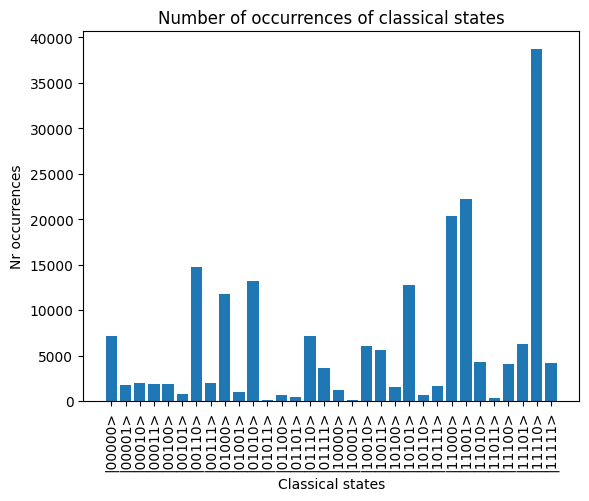

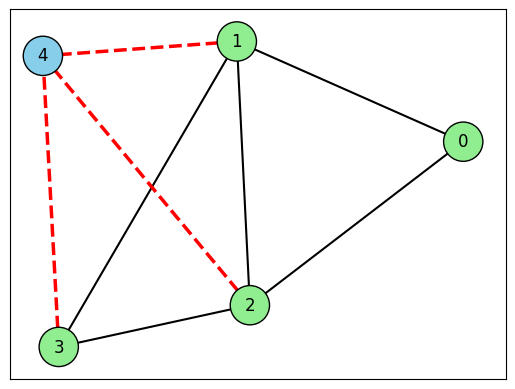

In [56]:
nr_measurements = 200000
p = 50
gamma = []
beta = []
for layer in range(p):
    gamma.append(gamma_max * (layer/p))
    beta.append(beta_max * ((p - layer)/p))
circuit = qaoa_circuit_noisy(gamma, beta, nodes, edges, p=p)
result = QuantumUtil.measure_circuit(circuit, nr_measurements=nr_measurements)

average_cut_size = compute_average_cut_size(nodes, edges, result)
partition = compute_partition(nodes, edges, result)
partition_cut_size = cut_size(edges, partition)

print(f"Partition {partition} has cut size {partition_cut_size}")
print(f"Average cut size is {average_cut_size}")
QuantumUtil.histogram_of_classical_states(result)
show_graph_partition(nodes, edges, partition)

Partition {0: 0, 1: 0, 2: 1, 3: 0, 4: 1} has cut size 5
Average cut size is 4.442095


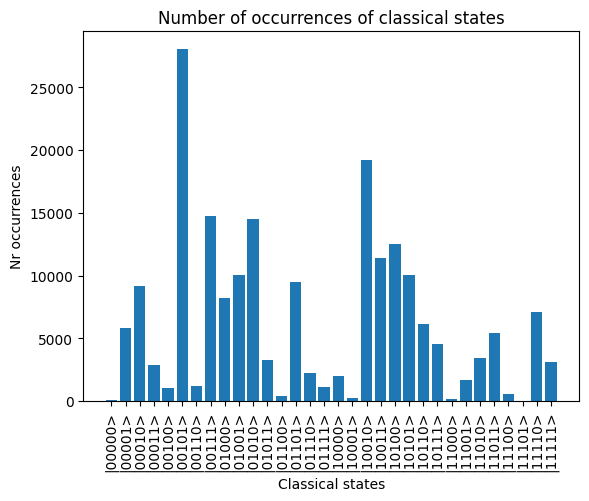

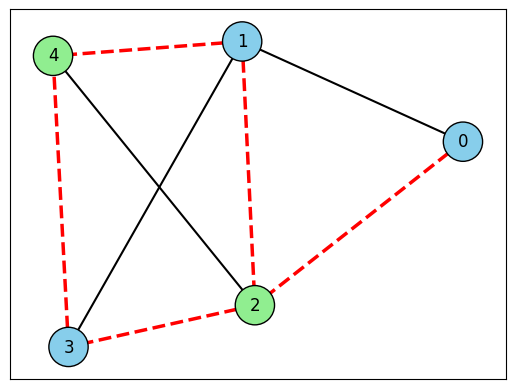

In [ ]:
nr_measurements = 200000
p = 50
gamma_max = 2.564383993829948
beta_max = 2.5839223662354627
gamma = []
beta = []
for layer in range(p):
    gamma.append(gamma_max * (layer/p))
    beta.append(beta_max * ((p - layer)/p))
circuit = qaoa_circuit_noisy(gamma, beta, nodes, edges, p=p)
result = QuantumUtil.measure_circuit(circuit, nr_measurements=nr_measurements)

average_cut_size = compute_average_cut_size(nodes, edges, result)
partition = compute_partition(nodes, edges, result)
partition_cut_size = cut_size(edges, partition)

print(f"Partition {partition} has cut size {partition_cut_size}")
print(f"Average cut size is {average_cut_size}")
QuantumUtil.histogram_of_classical_states(result)
show_graph_partition(nodes, edges, partition)